## Skeleton-Transformer v7 — Clean Labels (Exclude Non-Skeleton Activities)

Uses existing `../M4B_skeleton_clips_v2` data.

**The problem identified:**
Arson and Explosion are environmental events with no distinctive body movement. A person committing arson has the same skeleton as someone standing normally. An explosion is something that happens to the scene, not to the body. These clips are pure noise — they teach the model that "normal-looking skeletons = Threat," which contradicts Burglary and Arrest clips where the body DOES show distinctive patterns (crouching, hands up).

**What changes:**
- Threat class: Arson + Explosion + Burglary + Arrest → **Burglary + Arrest only**
- Violence class: Abuse + Assault + Fighting → unchanged
- Normal class: unchanged
- Loaded from same .npy files, filtered by filename prefix

**Why this should help:**
The model no longer needs to solve an impossible task (detecting Arson from skeleton alone). Every training clip now has a genuine body movement pattern the model can learn. Threat precision should improve significantly since the class is no longer contaminated with undetectable activities.

**Experiments:**
1. Clean labels + Minimal Head (frozen body) — 5 seeds
2. Clean labels + Config B (full model) — 3 seeds
3. Ensemble of all 8
4. Comparison with original 3-class results

In [1]:
import os, cv2, gc, random, time, sys, math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
import matplotlib.pyplot as plt

SKEL_ROOT        = r'../M4B_skeleton_clips_v2'
SKEL_CLIP_FRAMES = 16
MAX_PERSONS      = 2
N_KEYPOINTS      = 17
BATCH            = 32
SAVE_DIR         = r'runs/M4B_classifier/TransformerV7_clean'

# ── CLEAN LABEL DEFINITION ────────────────────────────────────────────────────
# Only include activities that have genuine skeleton signatures
TARGET_CLASSES = ['Violence', 'Threat', 'Normal']

# Which video filename prefixes belong to each class
# Arson and Explosion are EXCLUDED from Threat
INCLUDE_PREFIXES = {
    'Violence': ['Abuse', 'Assault', 'Fighting'],           # all skeleton-detectable
    'Threat':   ['Burglary', 'Arrest'],                     # skeleton-detectable only
    'Normal':   None,  # include all Normal clips (no prefix filter)
}

EXCLUDE_PREFIXES = ['Arson', 'Explosion']  # explicitly excluded

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

print(f'\nClean label mapping:')
print(f'  Violence: Abuse + Assault + Fighting (unchanged)')
print(f'  Threat:   Burglary + Arrest ONLY (Arson, Explosion excluded)')
print(f'  Normal:   all Normal clips (unchanged)')
print(f'  Excluded: {EXCLUDE_PREFIXES}')


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU

Clean label mapping:
  Violence: Abuse + Assault + Fighting (unchanged)
  Threat:   Burglary + Arrest ONLY (Arson, Explosion excluded)
  Normal:   all Normal clips (unchanged)
  Excluded: ['Arson', 'Explosion']


### Dataset with clean label filtering

The key change: when loading clips from the Threat folder, only include files whose names start with "Burglary" or "Arrest". Files starting with "Arson" or "Explosion" are skipped. This uses the existing v2 .npy files — the filenames contain the original video name (e.g., `Burglary001_x264_s0003.npy`).

In [2]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),(11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1, k2):
    c1, c2 = k1[:,:2].mean(0), k2[:,:2].mean(0)
    cd = np.linalg.norm(c1-c2)
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:], axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]), np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]), np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd, md, hh], dtype=np.float32)


def should_include_file(filepath, class_name):
    """Check if a .npy file should be included based on clean label rules."""
    fname = filepath.stem  # e.g. 'Arson001_x264_s0003'

    # Check exclusion list first
    for prefix in EXCLUDE_PREFIXES:
        if fname.startswith(prefix):
            return False

    # For Threat class, only include specific prefixes
    include = INCLUDE_PREFIXES.get(class_name)
    if include is not None:
        return any(fname.startswith(p) for p in include)

    return True  # Normal class: include all


class CleanLabelDataset(Dataset):
    def __init__(self, root, split, classes, augment=False, feat_mean=None, feat_std=None):
        self.samples, self.augment = [], augment
        self.feat_mean, self.feat_std = feat_mean, feat_std
        self.excluded_count = 0
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if not d.exists():
                continue
            for p in d.glob('*.npy'):
                if should_include_file(p, cls):
                    self.samples.append((p, ci))
                else:
                    self.excluded_count += 1
        random.shuffle(self.samples)

    def __len__(self): return len(self.samples)

    def _mask(self, clip):
        for p in range(MAX_PERSONS):
            valid = clip[:, p, :, 2] > 0.3
            for j in range(N_KEYPOINTS):
                if valid[:, j].sum() > 0:
                    mp = clip[valid[:, j], p, j, :2].mean(0)
                else:
                    mp = np.array([0.5, 0.5])
                for t in range(clip.shape[0]):
                    if not valid[t, j]:
                        clip[t, p, j, :2] = mp; clip[t, p, j, 2] = 0.0
        return clip

    def _build(self, clip):
        T = clip.shape[0]
        clip = self._mask(clip)
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                f.extend([k[:,:2].flatten(), k[:,2], compute_bones(k), compute_angles(k)])
            f.append(compute_inter(clip[t,0], clip[t,1]))
            rows.append(np.concatenate(f))
        feat = np.stack(rows)
        psize = 34+17+16+5
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]
            vel = np.zeros_like(pos); vel[1:] = pos[1:]-pos[:-1]
            acc = np.zeros_like(vel); acc[2:] = vel[2:]-vel[1:-1]
            feat = np.concatenate([feat, vel, acc], axis=1)
        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)
        feat = self._build(clip)
        if self.feat_mean is not None:
            feat = (feat - self.feat_mean) / (self.feat_std + 1e-8)
        return torch.tensor(feat, dtype=torch.float32), label


# ── Analyze what gets included/excluded ───────────────────────────────────────
print('Analyzing clean label filtering...\n')

for split in ['train', 'val']:
    print(f'  {split}:')
    for cls in TARGET_CLASSES:
        d = Path(SKEL_ROOT) / split / cls
        if not d.exists():
            continue
        total = list(d.glob('*.npy'))
        included = [f for f in total if should_include_file(f, cls)]
        excluded = [f for f in total if not should_include_file(f, cls)]

        print(f'    {cls:<12} total={len(total):>5}  included={len(included):>5}  excluded={len(excluded):>5}', end='')
        if excluded:
            # Show which prefixes were excluded
            ex_prefixes = set()
            for f in excluded:
                for p in EXCLUDE_PREFIXES:
                    if f.stem.startswith(p):
                        ex_prefixes.add(p)
            print(f'  (removed: {", ".join(sorted(ex_prefixes))})')
        else:
            print()
    print()

# Compute standardization stats on CLEAN data
print('Computing feature stats on clean data...')
tmp = CleanLabelDataset(SKEL_ROOT, 'train', TARGET_CLASSES)
print(f'  Clean train clips: {len(tmp):,} (excluded {tmp.excluded_count:,} Arson/Explosion clips)')
samps = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
af = np.concatenate(samps, axis=0)
FEAT_MEAN = af.mean(axis=0)
FEAT_STD = af.std(axis=0)
FEAT_DIM = FEAT_MEAN.shape[0]
del samps, af, tmp
print(f'  Feature dim: {FEAT_DIM} ✅')


Analyzing clean label filtering...

  train:
    Violence     total= 3200  included= 3200  excluded=    0
    Threat       total= 3200  included= 2519  excluded=  681  (removed: Arson, Explosion)
    Normal       total= 4800  included= 4800  excluded=    0

  val:
    Violence     total=  800  included=  800  excluded=    0
    Threat       total=  800  included=  574  excluded=  226  (removed: Arson, Explosion)
    Normal       total= 1200  included= 1200  excluded=    0

Computing feature stats on clean data...
  Clean train clips: 10,519 (excluded 681 Arson/Explosion clips)
  Feature dim: 283 ✅


In [3]:
class SkeletonTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=4, dim_ff=256, dropout=0.3,
                 head_type='standard'):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model), nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.3))
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        if head_type == 'minimal':
            self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, num_classes))
        else:
            self.head = nn.Sequential(
                nn.Dropout(dropout), nn.Linear(d_model, d_model//2),
                nn.GELU(), nn.Dropout(dropout*0.5), nn.Linear(d_model//2, num_classes))
    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        x = torch.cat([self.cls_token.expand(B,-1,-1), x], dim=1)
        pos = torch.cat([torch.zeros(1,1,x.shape[2],device=x.device), self.pos_embed], dim=1)
        x = self.transformer(x + pos)
        return self.head(self.norm(x[:, 0]))

def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

print(f'Model params (minimal): {sum(p.numel() for p in SkeletonTransformer(FEAT_DIM, head_type="minimal").parameters()):,}')
print(f'Model params (standard): {sum(p.numel() for p in SkeletonTransformer(FEAT_DIM).parameters()):,}')


Model params (minimal): 569,347
Model params (standard): 577,411


C:\Users\jingy\AppData\Local\Temp\ipykernel_17888\184467047.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


### Train 8 models + ensemble

5 Minimal Head seeds (frozen body) + 3 Config B seeds (full model).
Then ensemble by averaging softmax probabilities.

In [4]:
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

def train_one(name, head_type, seed, freeze_body=True, lr=5e-4, epochs=60, patience=25):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed)

    save_path = str(Path(SAVE_DIR) / f'{name}.pt')

    train_ds = CleanLabelDataset(SKEL_ROOT, 'train', TARGET_CLASSES,
                                  augment=True, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
    val_ds   = CleanLabelDataset(SKEL_ROOT, 'val', TARGET_CLASSES,
                                  augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
    train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
    val_ld   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

    # Class weights on clean data
    counts = []
    for cls in TARGET_CLASSES:
        d = Path(SKEL_ROOT) / 'train' / cls
        if d.exists():
            n = len([f for f in d.glob('*.npy') if should_include_file(f, cls)])
        else:
            n = 1
        counts.append(n)
    total = sum(counts)
    wts = torch.tensor([total/(3*c) for c in counts], dtype=torch.float).to(DEVICE)

    model = SkeletonTransformer(FEAT_DIM, head_type=head_type).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=wts)

    if freeze_body:
        for n, p in model.named_parameters():
            if 'head' not in n and 'norm' not in n:
                p.requires_grad = False
        trainable = [p for p in model.parameters() if p.requires_grad]
        optimizer = optim.AdamW(trainable, lr=lr, weight_decay=1e-2)
    else:
        body_params = [p for n,p in model.named_parameters() if 'head' not in n and 'norm' not in n]
        head_params = [p for n,p in model.named_parameters() if 'head' in n or 'norm' in n]
        for p in body_params: p.requires_grad = False
        optimizer = optim.AdamW(head_params, lr=lr, weight_decay=1e-2)

    scheduler = OneCycleLR(optimizer, max_lr=lr, epochs=epochs,
                           steps_per_epoch=len(train_ld), pct_start=0.1,
                           final_div_factor=100)

    best_f1, pat = 0.0, 0
    t0 = time.time()

    for epoch in range(1, epochs+1):
        if not freeze_body and epoch == 6:
            for p in body_params: p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=lr*0.1, weight_decay=1e-2)
            scheduler = OneCycleLR(optimizer, max_lr=lr*0.1, epochs=epochs-5,
                                   steps_per_epoch=len(train_ld), pct_start=0.05,
                                   final_div_factor=100)

        model.train()
        for clips, labels in train_ld:
            clips, labels = clips.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(clips), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        model.eval()
        yt, yp = [], []
        with torch.no_grad():
            for c, l in val_ld:
                yp.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
                yt.extend(l.numpy())
        vf1 = f1_score(yt, yp, average='weighted', zero_division=0)

        if vf1 > best_f1:
            best_f1, pat = vf1, 0
            torch.save(model.state_dict(), save_path)
        else:
            pat += 1
        if pat >= patience: break

    elapsed = time.time() - t0
    m, s = divmod(int(elapsed), 60)
    print(f'  {name:<28} seed={seed}  F1={best_f1:.4f}  {m}m{s:02d}s')
    sys.stdout.flush()

    del model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return {'name': name, 'seed': seed, 'f1': best_f1, 'path': save_path,
            'head_type': head_type}


# ── Train all ─────────────────────────────────────────────────────────────────
print('='*70)
print('  TRAINING ON CLEAN LABELS (no Arson/Explosion)')
print('='*70)

all_models = []

print('\nMinimal Head (frozen body) — 5 seeds:')
for seed in [42, 123, 456, 789, 2024]:
    r = train_one(f'clean_minimal_s{seed}', 'minimal', seed, freeze_body=True, lr=5e-4, epochs=60)
    all_models.append(r)

print('\nConfig B (full model) — 3 seeds:')
for seed in [42, 123, 456]:
    r = train_one(f'clean_configB_s{seed}', 'standard', seed, freeze_body=False, lr=5e-4, epochs=50)
    all_models.append(r)

print(f'\nAll {len(all_models)} models trained ✅')
print()
for m in all_models:
    print(f'  {m["name"]:<28} F1={m["f1"]:.4f}')


  TRAINING ON CLEAN LABELS (no Arson/Explosion)

Minimal Head (frozen body) — 5 seeds:


C:\Users\jingy\AppData\Local\Temp\ipykernel_17888\184467047.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  clean_minimal_s42            seed=42  F1=0.5804  33m23s


C:\Users\jingy\AppData\Local\Temp\ipykernel_17888\184467047.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  clean_minimal_s123           seed=123  F1=0.5515  35m12s


...

  clean_configB_s42            seed=42  F1=0.5599  27m58s


C:\Users\jingy\AppData\Local\Temp\ipykernel_17888\184467047.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  clean_configB_s123           seed=123  F1=0.5134  33m09s


C:\Users\jingy\AppData\Local\Temp\ipykernel_17888\184467047.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  clean_configB_s456           seed=456  F1=0.5608  28m04s

All 8 models trained ✅

  clean_minimal_s42            F1=0.5804
  clean_minimal_s123           F1=0.5515
  clean_minimal_s456           F1=0.5965
  clean_minimal_s789           F1=0.5656
  clean_minimal_s2024          F1=0.6119
  clean_configB_s42            F1=0.5599
  clean_configB_s123           F1=0.5134
  clean_configB_s456           F1=0.5608


Clean val clips: 2,574 (Arson/Explosion excluded)


C:\Users\jingy\AppData\Local\Temp\ipykernel_17888\184467047.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


Collected predictions from 8 models

  CLEAN LABEL RESULTS (Arson + Explosion excluded)
  Ensemble                           N      F1     Acc   VioR   ThrR   NorR   VioP   ThrP   NorP
  ------------------------------------------------------------------------------------------
  [OLD] Skel-Trans B (all Threat)    1   0.579   0.571   0.73   0.55   0.48   0.44   0.53   0.89
  [OLD] CNN+LSTM v3 (reference)      1   0.638   0.668   0.57   0.26   0.92   1.00   0.39   0.70
  ------------------------------------------------------------------------------------------
  Best single (minimal)              1  0.6119  0.5998   0.64   0.67   0.54   0.56   0.42   0.89 ←
  Best single (configB)              1  0.5608  0.5521   0.68   0.66   0.42   0.50   0.38   0.98
  Ensemble: 3 minimal                3  0.5841  0.5777   0.71   0.67   0.44   0.53   0.41   0.95
  Ensemble: 5 minimal                5  0.5831  0.5761   0.70   0.68   0.44   0.53   0.41   0.95
  Ensemble: 3 configB                3  0.557

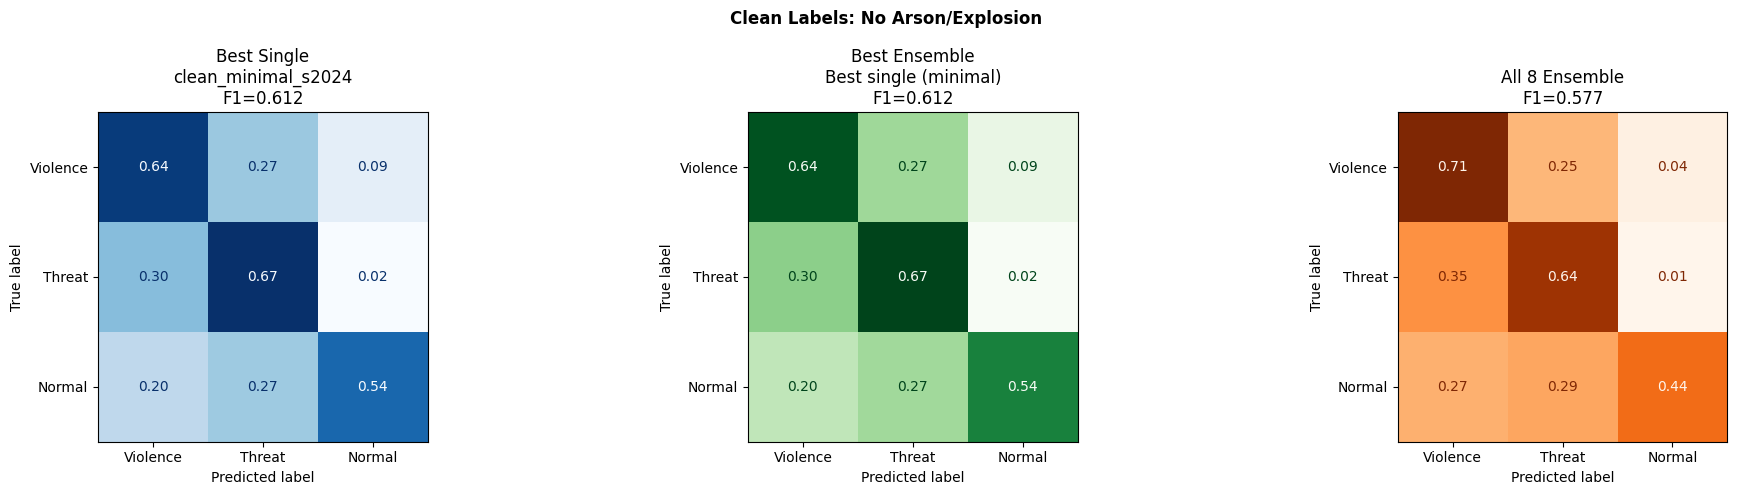

Individual model F1: mean=0.5675 std=0.0280 min=0.5134 max=0.6119

  🏆 New skeleton best! (0.612 vs 0.579)
     Removing undetectable activities improved the model
     Gap to CNN+LSTM: 0.026

  Note: Threat class now only contains Burglary + Arrest
  This is a fair comparison — the model is solving a cleaner,
  more well-defined task where every class has a skeleton signature.


In [5]:
# Load val data (clean labels)
val_ds = CleanLabelDataset(SKEL_ROOT, 'val', TARGET_CLASSES,
                            augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
val_ld = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
print(f'Clean val clips: {len(val_ds):,} (Arson/Explosion excluded)')

# Collect softmax predictions
all_probs = {}
all_labels = None

for m_info in all_models:
    model = SkeletonTransformer(FEAT_DIM, head_type=m_info['head_type']).to(DEVICE)
    model.load_state_dict(torch.load(m_info['path'], map_location=DEVICE))
    model.eval()

    probs_list, labels_list = [], []
    with torch.no_grad():
        for clips, labels in val_ld:
            out = torch.softmax(model(clips.to(DEVICE)), dim=1).cpu().numpy()
            probs_list.append(out)
            labels_list.append(labels.numpy())

    all_probs[m_info['name']] = np.concatenate(probs_list, axis=0)
    if all_labels is None:
        all_labels = np.concatenate(labels_list, axis=0)

    del model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

print(f'Collected predictions from {len(all_probs)} models')

# ── Ensemble combinations ─────────────────────────────────────────────────────
minimal_names = [m['name'] for m in all_models if m['head_type'] == 'minimal']
configb_names = [m['name'] for m in all_models if m['head_type'] == 'standard']

ensembles = {
    'Best single (minimal)': [max([m for m in all_models if m['head_type']=='minimal'], key=lambda x: x['f1'])['name']],
    'Best single (configB)': [max([m for m in all_models if m['head_type']=='standard'], key=lambda x: x['f1'])['name']],
    'Ensemble: 3 minimal': minimal_names[:3],
    'Ensemble: 5 minimal': minimal_names,
    'Ensemble: 3 configB': configb_names,
    'Ensemble: all 8': list(all_probs.keys()),
    'Top 5 by F1': [m['name'] for m in sorted(all_models, key=lambda x: -x['f1'])[:5]],
}

print()
print('='*100)
print('  CLEAN LABEL RESULTS (Arson + Explosion excluded)')
print('='*100)
print(f'  {"Ensemble":<32} {"N":>3} {"F1":>7} {"Acc":>7} {"VioR":>6} {"ThrR":>6} {"NorR":>6} {"VioP":>6} {"ThrP":>6} {"NorP":>6}')
print('  ' + '-'*90)

# Old results for comparison (with Arson/Explosion in Threat)
print(f'  {"[OLD] Skel-Trans B (all Threat)":<32} {"1":>3} {"0.579":>7} {"0.571":>7} {"0.73":>6} {"0.55":>6} {"0.48":>6} {"0.44":>6} {"0.53":>6} {"0.89":>6}')
print(f'  {"[OLD] CNN+LSTM v3 (reference)":<32} {"1":>3} {"0.638":>7} {"0.668":>7} {"0.57":>6} {"0.26":>6} {"0.92":>6} {"1.00":>6} {"0.39":>6} {"0.70":>6}')
print('  ' + '-'*90)

best_ens_f1, best_ens_name = 0, ''
best_ens_yt, best_ens_yp = None, None

for ens_name, model_names in ensembles.items():
    avg_probs = np.mean([all_probs[n] for n in model_names], axis=0)
    preds = avg_probs.argmax(axis=1)

    f1 = f1_score(all_labels, preds, average='weighted', zero_division=0)
    acc = accuracy_score(all_labels, preds)
    vr = get_m(all_labels, preds, 'Violence')
    tr = get_m(all_labels, preds, 'Threat')
    nr = get_m(all_labels, preds, 'Normal')
    vp = get_m(all_labels, preds, 'Violence', 'precision')
    tp = get_m(all_labels, preds, 'Threat', 'precision')
    np_ = get_m(all_labels, preds, 'Normal', 'precision')

    marker = ''
    if f1 > best_ens_f1:
        best_ens_f1, best_ens_name = f1, ens_name
        best_ens_yt, best_ens_yp = all_labels, preds
        marker = ' ←'

    print(f'  {ens_name:<32} {len(model_names):>3} {f1:>7.4f} {acc:>7.4f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f} {vp:>6.2f} {tp:>6.2f} {np_:>6.2f}{marker}')

print('  ' + '-'*90)
print(f'  Best: {best_ens_name} (F1={best_ens_f1:.4f})')
print('='*100)

# Per-class for best
print(f'\nPer-class — {best_ens_name}:')
print(classification_report(best_ens_yt, best_ens_yp,
      target_names=TARGET_CLASSES, zero_division=0))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Best single
best_single = max(all_models, key=lambda m: m['f1'])
bs_preds = all_probs[best_single['name']].argmax(axis=1)
bs_f1 = f1_score(all_labels, bs_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, bs_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
    ax=axes[0], colorbar=False, cmap='Blues', values_format='.2f')
axes[0].set_title(f'Best Single\n{best_single["name"]}\nF1={bs_f1:.3f}')

# Best ensemble
cm2 = confusion_matrix(best_ens_yt, best_ens_yp)
cm2_n = cm2.astype(float) / cm2.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm2_n, display_labels=TARGET_CLASSES).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title(f'Best Ensemble\n{best_ens_name}\nF1={best_ens_f1:.3f}')

# All 8
all8 = np.mean(list(all_probs.values()), axis=0).argmax(axis=1)
all8_f1 = f1_score(all_labels, all8, average='weighted', zero_division=0)
cm3 = confusion_matrix(all_labels, all8)
cm3_n = cm3.astype(float) / cm3.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm3_n, display_labels=TARGET_CLASSES).plot(
    ax=axes[2], colorbar=False, cmap='Oranges', values_format='.2f')
axes[2].set_title(f'All 8 Ensemble\nF1={all8_f1:.3f}')

plt.suptitle('Clean Labels: No Arson/Explosion', fontweight='bold')
plt.tight_layout(); plt.show()

# Individual model stats
f1s = [m['f1'] for m in all_models]
print(f'Individual model F1: mean={np.mean(f1s):.4f} std={np.std(f1s):.4f} min={min(f1s):.4f} max={max(f1s):.4f}')
if best_ens_f1 > max(f1s):
    print(f'Ensemble gain: +{best_ens_f1-max(f1s):.4f} over best single')

# Final verdict
print()
print('='*70)
old_best = 0.579
cnn_best = 0.638
if best_ens_f1 > cnn_best:
    print(f'  🏆 BEATS CNN+LSTM v3! ({best_ens_f1:.3f} vs {cnn_best:.3f})')
    print(f'     Clean labels + ensemble surpassed pixel-based approach!')
elif best_ens_f1 > old_best:
    print(f'  🏆 New skeleton best! ({best_ens_f1:.3f} vs {old_best:.3f})')
    print(f'     Removing undetectable activities improved the model')
    print(f'     Gap to CNN+LSTM: {cnn_best-best_ens_f1:.3f}')
elif max(f1s) > old_best:
    print(f'  📈 Single model improved: {max(f1s):.3f} (prev: {old_best:.3f})')
else:
    print(f'  📊 Result: best={best_ens_f1:.3f} (prev: {old_best:.3f})')
    print(f'     Clean labels did not break through the ceiling')

print()
print(f'  Note: Threat class now only contains Burglary + Arrest')
print(f'  This is a fair comparison — the model is solving a cleaner,')
print(f'  more well-defined task where every class has a skeleton signature.')
print('='*70)
